### Calculate Track Frequency


Code compiled from clee and skramer

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import sys
import os, glob
import xarray as xr


## most correct would probably be to seperate this... 
### get variables from chaz run
import Namelist as gv


In [2]:
# ======================
# Model configurations
# ======================

model_configs = {
    "ERA5-Original-CHAZ": {
        "base_dir": "/xpt/taroko.local/data0/clee/ERA5/wdir/netcdf/",
        "ensemble_dirs": ["."],
        "sub_dir": ".",
        "file_pattern": "global_2019_2ens*_pre.nc",\
        "year_range": (gv.Year1, gv.Year2),
        #"year_range": (1950, 2020),                                      
        "output_dir": gv.output_path,
        "name": "ERA5-Original-CHAZ"
    },
     "ERA5-Updated-CHAZ": {
        "base_dir": gv.output_path,
        "ensemble_dirs": ["."],
        "sub_dir": ".",
        "file_pattern": "ERA5_*_ens0*.nc",
        "year_range": (gv.Year1, gv.Year2),
        "output_dir": gv.output_path,
        "name": "ERA5-Updated-CHAZ"
    }
}


In [3]:
# ============================================================
# Track-FREQUENCY for CHAZ–ERA models (ERA5, ERA-Interim)
# ============================================================
# Track frequency = unique storms visiting each grid cell (storms/year/gridcell)
# (as opposed to track density, which counts track points/time-steps).
#
# Outputs NPZ per basin (ATL/WNP/GLOBAL) with:
#   frequency [lat, lon], lon_edges, lat_edges, nyears_eff, etc.
# ============================================================


# ----------------------
# Helpers
# ----------------------
def _to_0_360(lon):
    """Convert longitude array to [0, 360)."""
    return np.mod(lon, 360.0)

def _basin_bounds_0360(basin_key):
    """
    Basin bounds in 0–360E coordinates.

    ATL: ~100°W–20°E, 0–60°N  -> 260–380 (wrap handled)
    WNP: ~100°E–180°E, 0–50°N -> 100–180
    GLOBAL: 0–360, -60–60 (you can adjust)
    """
    if basin_key == "ATL":
        return (260.0, 380.0, 0.0, 60.0)
    elif basin_key == "WNP":
        return (100.0, 180.0, 0.0, 50.0)
    elif basin_key == "GLOBAL":
        return (0.0, 360.0, -60.0, 60.0)
    else:
        raise ValueError(f"Unknown basin_key={basin_key!r}")

def _enumerate_model_files(cfg):
    """
    Enumerate NetCDF storm catalogs for a given model config (ERA-style).

    Returns
    -------
    files : list[str]
    nyears_eff : int
        Effective years = years_span × number_of_files (matches your RP philosophy)
    """
    base_dir      = cfg["base_dir"]
    ensemble_dirs = cfg.get("ensemble_dirs", ["."])
    sub_dir       = cfg.get("sub_dir", ".")
    file_pattern  = cfg["file_pattern"]
    year_range    = cfg["year_range"]
    name          = cfg["name"]


    file_lists = []
    for ens in ensemble_dirs:
        ens_dir = os.path.join(base_dir, ens, sub_dir) if sub_dir != "." else os.path.join(base_dir, ens)
        file_lists.append(glob.glob(os.path.join(ens_dir, file_pattern)))

    # files = [f for sublist in file_lists for f in sublist]
    # files = sorted(files)
    files = sorted([f for sublist in file_lists for f in sublist])

    years_span = year_range[1] - year_range[0] + 1
    # nyears_eff = years_span * max(1, len(files))

    
    if name == 'ERA5-Updated-CHAZ':
        years = {str(y) for y in range(year_range[0], year_range[1] + 1)}
        fnames = sorted([
            f for f in files
            if f.split('_')[1] in years])

        nyears_eff = len(fnames)

    elif name == 'ERA5-Original-CHAZ':
        fnames = sorted(files)
        nyears_eff = years_span * max(1, len(fnames))

    else:
        raise ValueError(f"Unknown configuration: {name}")
    # if name == "ERA5-Updated-CHAZ":
    #         ## each file is an independent realization and year 
    #     nyears_eff = len(files)
    # else: 
    #     ### original data in clee folder
    #     nyears_eff = years_span * max(1, len(files))  # each file is an independent realization

    return fnames, nyears_eff
    #return files, nyears_eff



In [4]:

# ------------------------------------------------------------
# Core: collect per-point lon/lat PLUS storm ids (for frequency)
# ------------------------------------------------------------
def collect_track_points_with_storm_ids_for_model(
    model_key,
    configs=None,
    min_wind_knots=34.0,
):
    """
    Collect thresholded track points and a storm-id per point, across all files.

    Returns
    -------
    lon_all, lat_all : 1D arrays (0–360E)
    sid_all : 1D array of int64, same length as lon/lat
        Unique per-storm identifier across the entire pooled dataset.
        (file_index, storm_index) is encoded into a single int.
    nyears_eff : int
    """
    if configs is None:
        configs = model_configs

    cfg = configs[model_key]
    files, nyears_eff = _enumerate_model_files(cfg)
    year_range = cfg["year_range"]
    yr0, yr1 = year_range

    lon_all = []
    lat_all = []
    sid_all = []

    for fi, f in enumerate(files):
        try:
            ds = xr.open_dataset(f)
        except Exception as e:
            print(f"[WARN] Could not open {os.path.basename(f)}: {type(e).__name__}: {e}")
            continue

        try:
            if "Mwspd" not in ds or "longitude" not in ds or "latitude" not in ds:
                continue

            # Winds
            w_da = ds["Mwspd"]
            if "ensembleNum" in w_da.dims:
                w_da = w_da.isel(ensembleNum=0)
            wspd = w_da.values  # [time, storm]

            # Coordinates
            lon_da = ds["longitude"]
            lat_da = ds["latitude"]
            if "ensembleNum" in lon_da.dims:
                lon_da = lon_da.isel(ensembleNum=0)
                lat_da = lat_da.isel(ensembleNum=0)
            lon = lon_da.values
            lat = lat_da.values

            # Per-storm years (if available)
            if "year" in ds:
                years_storm = ds["year"].values  # [storm]
                years_2d = np.broadcast_to(years_storm[np.newaxis, :], wspd.shape)
            else:
                years_2d = np.full(wspd.shape, yr0, dtype=int)

        finally:
            ds.close()

        # Clean / normalize
        lon = np.where(lon == -9999, np.nan, lon)
        lat = np.where(lat == -9999, np.nan, lat)
        wspd = np.where(wspd == -9999, np.nan, wspd)
        lon = np.where(lon < 0, lon + 360.0, lon)

        base_mask = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(wspd) & np.isfinite(years_2d)
        year_mask = (years_2d >= yr0) & (years_2d <= yr1)
        wind_mask = (wspd >= min_wind_knots)

        mask = base_mask & year_mask & wind_mask
        if not np.any(mask):
            continue

        # Encode per-storm IDs uniquely across files:
        # sid = fi * 1_000_000 + storm_index
        # (1e6 is safely > typical storm counts per file)
        nstorm = wspd.shape[1]
        storm_ids_1d = (fi * 1_000_000 + np.arange(nstorm, dtype=np.int64))
        storm_ids_2d = np.broadcast_to(storm_ids_1d[np.newaxis, :], wspd.shape)

        lon_all.append(lon[mask])
        lat_all.append(lat[mask])
        sid_all.append(storm_ids_2d[mask])

    if not lon_all:
        raise RuntimeError(f"No qualifying track points found for {model_key} — check files & thresholds.")

    lon_all = np.concatenate(lon_all).astype(float)
    lat_all = np.concatenate(lat_all).astype(float)
    sid_all = np.concatenate(sid_all).astype(np.int64)

    print(f"{model_key}: collected {lon_all.size} points ≥ {min_wind_knots} kt; effective years = {nyears_eff}")
    return lon_all, lat_all, sid_all, nyears_eff

# ------------------------------------------------------------
# Compute basin track frequency (unique storms per cell per year)
# ------------------------------------------------------------
def compute_basin_track_frequency_for_model(
    lon_all,
    lat_all,
    sid_all,
    nyears_eff,
    basin_key,
    dlon=2.0,
    dlat=2.0,
    lon_min_global=0.0,
    lon_max_global=360.0,
    lat_min_global=-60.0,
    lat_max_global=60.0,
):
    """
    Track frequency = number of unique storms visiting each grid cell, normalized by nyears_eff.

    Returns
    -------
    freq : 2D array [n_lat, n_lon] (storms/year/gridcell)
    lon_edges : 1D array
    lat_edges : 1D array
    """
    lon_all = _to_0_360(lon_all)

    lon_edges = np.arange(lon_min_global, lon_max_global + dlon, dlon)
    lat_edges = np.arange(lat_min_global, lat_max_global + dlat, dlat)

    lon_min, lon_max, lat_min, lat_max = _basin_bounds_0360(basin_key)

    # Basin mask; ATL wraps 360 (260–380)
    basin_key = basin_key.upper()
    if basin_key == "ATL":
        basin_mask = ((lon_all >= lon_min) | (lon_all < lon_max - 360.0)) & \
                     (lat_all >= lat_min) & (lat_all <= lat_max)
    elif basin_key == "WNP":
        basin_mask = (lon_all >= lon_min) & (lon_all < lon_max) & \
                     (lat_all >= lat_min) & (lat_all <= lat_max)
    elif basin_key == "GLOBAL":
        # no wrap needed; allow full domain you requested
        basin_mask = (lon_all >= lon_min) & (lon_all < lon_max) & \
                     (lat_all >= lat_min) & (lat_all <= lat_max)
    else:
        raise ValueError(f"Unknown basin_key={basin_key}")

    lon_b = lon_all[basin_mask]
    lat_b = lat_all[basin_mask]
    sid_b = sid_all[basin_mask]

    if lon_b.size == 0:
        freq = np.zeros((lat_edges.size - 1, lon_edges.size - 1), dtype=float)
        return freq, lon_edges, lat_edges

    # Convert points to grid indices
    i = np.searchsorted(lon_edges, lon_b, side="right") - 1
    j = np.searchsorted(lat_edges, lat_b, side="right") - 1

    ok = (i >= 0) & (i < (lon_edges.size - 1)) & (j >= 0) & (j < (lat_edges.size - 1))
    i = i[ok].astype(np.int64)
    j = j[ok].astype(np.int64)
    sid = sid_b[ok].astype(np.int64)

    if i.size == 0:
        freq = np.zeros((lat_edges.size - 1, lon_edges.size - 1), dtype=float)
        return freq, lon_edges, lat_edges

    # Deduplicate: one count per (storm_id, cell)
    triples = np.stack([sid, j, i], axis=1)
    uniq = np.unique(triples, axis=0)

    freq = np.zeros((lat_edges.size - 1, lon_edges.size - 1), dtype=float)
    jj = uniq[:, 1].astype(int)
    ii = uniq[:, 2].astype(int)
    np.add.at(freq, (jj, ii), 1.0)

    # Normalize to storms per year per cell
    freq = freq / float(nyears_eff)

    return freq, lon_edges, lat_edges

# ------------------------------------------------------------
# High-level driver: compute & save track FREQUENCY NPZs
# ------------------------------------------------------------
def compute_and_save_track_frequency_for_model(
    model_key,
    basins=("ATL", "WNP", "GLOBAL"),
    min_wind_knots=34.0,
    dlon=2.0,
    dlat=2.0,
    configs=None,
    lat_min_global=-60.0,
    lat_max_global=60.0,
):
    """
    Compute track frequency for one CHAZ–ERA model and save NPZ per basin:
      <output_dir>/TrackFrequency/track_frequency_<MODEL>_<BASIN>.npz
    """
    if configs is None:
        configs = model_configs

    if isinstance(basins, str):
        basins = (basins,)
    else:
        basins = tuple(basins)

    print(f"\n=== Track FREQUENCY for model: {model_key} (≥{min_wind_knots} kt) ===")
    lon_all, lat_all, sid_all, nyears_eff = collect_track_points_with_storm_ids_for_model(
        model_key,
        configs=configs,
        min_wind_knots=min_wind_knots,
    )

    cfg = configs[model_key]
    out_root = cfg["output_dir"]
    out_dir = os.path.join(out_root, "TrackFrequency")
    os.makedirs(out_dir, exist_ok=True)

    results = {}

    for basin_key in basins:
        print(f"  Computing basin frequency: {basin_key}")
        freq, lon_edges, lat_edges = compute_basin_track_frequency_for_model(
            lon_all, lat_all, sid_all, nyears_eff,
            basin_key=basin_key,
            dlon=dlon,
            dlat=dlat,
            lon_min_global=0.0,
            lon_max_global=360.0,
            lat_min_global=lat_min_global,
            lat_max_global=lat_max_global,
        )
        results[basin_key] = (freq, lon_edges, lat_edges)

        outpath = os.path.join(out_dir, f"track_frequency_{model_key}_{basin_key}.npz")
        np.savez(
            outpath,
            frequency=freq,
            lon_edges=lon_edges,
            lat_edges=lat_edges,
            nyears_eff=nyears_eff,
            min_wind_knots=min_wind_knots,
            dlon=dlon,
            dlat=dlat,
            basin_key=basin_key,
            definition="unique_storms_per_cell_per_year",
            model=model_key,
            year_range=np.array(cfg["year_range"]),
        )
        print(f"    Saved NPZ: {outpath}")

    return results


In [5]:
compute_and_save_track_frequency_for_model(
    model_key="ERA5-Original-CHAZ",
    basins=("GLOBAL", 'ATL', 'WNP'),
    min_wind_knots=34.0,
    dlon=2.0,
    dlat=2.0,
)



=== Track FREQUENCY for model: ERA5-Original-CHAZ (≥34.0 kt) ===
ERA5-Original-CHAZ: collected 1103386 points ≥ 34.0 kt; effective years = 600
  Computing basin frequency: GLOBAL
    Saved NPZ: output/TrackFrequency/track_frequency_ERA5-Original-CHAZ_GLOBAL.npz
  Computing basin frequency: ATL
    Saved NPZ: output/TrackFrequency/track_frequency_ERA5-Original-CHAZ_ATL.npz
  Computing basin frequency: WNP
    Saved NPZ: output/TrackFrequency/track_frequency_ERA5-Original-CHAZ_WNP.npz


{'GLOBAL': (array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.005     , 0.00333333,
          0.00166667],
         [0.        , 0.        , 0.        , ..., 0.00333333, 0.00833333,
          0.00833333],
         [0.        , 0.        , 0.        , ..., 0.01333333, 0.01      ,
          0.00333333]], shape=(60, 180)),
  array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
          22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
          44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
          66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
          88.,  90.,  92.,  94.,  96.,  98., 100., 102., 104., 106., 

In [6]:
compute_and_save_track_frequency_for_model(
    model_key="ERA5-Updated-CHAZ",
    basins=("GLOBAL", 'ATL', 'WNP'),
    min_wind_knots=34.0,
    dlon=2.0,
    dlat=2.0,
)



=== Track FREQUENCY for model: ERA5-Updated-CHAZ (≥34.0 kt) ===
ERA5-Updated-CHAZ: collected 167542 points ≥ 34.0 kt; effective years = 99
  Computing basin frequency: GLOBAL
    Saved NPZ: output/TrackFrequency/track_frequency_ERA5-Updated-CHAZ_GLOBAL.npz
  Computing basin frequency: ATL
    Saved NPZ: output/TrackFrequency/track_frequency_ERA5-Updated-CHAZ_ATL.npz
  Computing basin frequency: WNP
    Saved NPZ: output/TrackFrequency/track_frequency_ERA5-Updated-CHAZ_WNP.npz


{'GLOBAL': (array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.        ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
          0.01010101],
         [0.        , 0.        , 0.        , ..., 0.01010101, 0.01010101,
          0.02020202],
         [0.        , 0.        , 0.        , ..., 0.02020202, 0.01010101,
          0.01010101]], shape=(60, 180)),
  array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,
          22.,  24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,
          44.,  46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,
          66.,  68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,
          88.,  90.,  92.,  94.,  96.,  98., 100., 102., 104., 106., 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


def _prep_freq_for_plot(F, lon_edges, lat_edges):
    """
    Convert 0–360 lon_edges to continuous -180..180 edges and roll F
    so the seam is at -180.
    Returns LonE_plot, LatE_plot (edges mesh), F_plot (same shape as F).
    """
    lon_edges_plot = (lon_edges + 180.0) % 360.0 - 180.0
    seam = int(np.argmin(lon_edges_plot))

    lon_edges_plot_roll = np.roll(lon_edges_plot, -seam)
    LonE_plot, LatE_plot = np.meshgrid(lon_edges_plot_roll, lat_edges)

    F_roll = np.roll(F, -seam, axis=1)

    # Ensure monotonic edges if needed
    if np.any(np.diff(lon_edges_plot_roll) < 0):
        order = np.argsort(lon_edges_plot_roll)
        lon_edges_plot_roll = lon_edges_plot_roll[order]
        LonE_plot, LatE_plot = np.meshgrid(lon_edges_plot_roll, lat_edges)
        # For cell data, drop the last edge index
        F_roll = F_roll[:, order[:-1]]

    return LonE_plot, LatE_plot, F_roll


def _mask_below_min_freq(F, min_freq=0.01):
    """Mask cells with frequency < min_freq as NaN."""
    Fm = np.array(F, dtype=float, copy=True)
    Fm[Fm < min_freq] = np.nan
    return Fm


def plot_track_frequency_npz(
    npz_path,
    title=None,
    extent="auto",
    vmin=0.0,
    vmax=None,
    cmap="Blues",
    min_freq=None,               # e.g. 0.01
    extent_lat=(-60, 70),        # match your density domain preference
    central_longitude=0,         # Atlantic-centered
    mask_zeros=True,             # zeros -> NaN
    horizontal_cbar=True,        # match density style
):
    """
    Plot track frequency with the SAME styling as your track density plots:
      - ocean white
      - land light gray underneath
      - masked values transparent (so land shows through)
      - gridline labels
      - horizontal colorbar (default)
      - Atlantic-centered projection
    """
    d = np.load(npz_path, allow_pickle=True)

    F = d["frequency"].astype(float)
    lon_edges = d["lon_edges"].astype(float)
    lat_edges = d["lat_edges"].astype(float)

    basin_key = str(d["basin_key"]) if "basin_key" in d.files else None
    model = str(d["model"]) if "model" in d.files else None

    # years metadata can vary; support both styles
    if "year_range" in d.files:
        year_range = d["year_range"]
        if year_range is not None and len(year_range) == 2:
            start_year, end_year = int(year_range[0]), int(year_range[1])
        else:
            start_year = end_year = None
    else:
        start_year = int(d["start_year"]) if "start_year" in d.files else None
        end_year = int(d["end_year"]) if "end_year" in d.files else None

    # Masking logic
    if min_freq is None:
        Fm = F.copy()
        if mask_zeros:
            Fm[Fm <= 0] = np.nan
    else:
        Fm = _mask_below_min_freq(F, min_freq=min_freq)

    LonE_plot, LatE_plot, F_plot = _prep_freq_for_plot(Fm, lon_edges, lat_edges)

    # extent selection (in -180..180 display coords)
    basin_up = (basin_key or "").upper()
    if extent == "auto":
        if basin_up == "ATL":
            ext = (-100, 20, 0, 60)
        elif basin_up == "WNP":
            ext = (100, 180, 0, 50)
        else:
            ext = (-180, 180, extent_lat[0], extent_lat[1])
    elif extent == "global":
        ext = (-180, 180, extent_lat[0], extent_lat[1])
    else:
        ext = extent

    # choose vmax
    if vmax is None:
        vmax = float(np.nanmax(F_plot)) if np.isfinite(F_plot).any() else 1.0

    # Colormap: NaNs -> transparent (so gray land shows)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad((1, 1, 1, 0))  # transparent

    fig = plt.figure(figsize=(12.5, 5.8))
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=central_longitude))

    # Background to match density style
    ax.set_facecolor("white")
    ax.add_feature(cfeature.LAND, facecolor="lightgray", edgecolor="none", zorder=0)

    ax.set_extent(ext, crs=ccrs.PlateCarree())

    pm = ax.pcolormesh(
        LonE_plot, LatE_plot, F_plot,
        transform=ccrs.PlateCarree(),
        vmin=vmin, vmax=vmax,
        cmap=cmap_obj,
        shading="auto",
        zorder=1
    )

    ax.coastlines(resolution="110m", linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5, zorder=3)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, linestyle="--", alpha=0.4, zorder=4)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 9}
    gl.ylabel_style = {"size": 9}

    if horizontal_cbar:
        cb = plt.colorbar(pm, ax=ax, orientation="horizontal", pad=0.08, fraction=0.05)
    else:
        cb = plt.colorbar(pm, ax=ax, orientation="vertical", pad=0.02, shrink=0.8)

    cb.set_label("Track frequency (unique storms / year / 2°×2° cell)")

    if title is None:
        yr_txt = f"{start_year}–{end_year}" if (start_year is not None and end_year is not None) else ""
        title = f"{model or ''} {basin_up or ''} track frequency {yr_txt}".strip()
        if min_freq is not None:
            title += f"  (freq ≥ {min_freq:g} shown)"
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


def plot_track_frequency_set(
    npz_paths,
    extent="auto",
    vmin=0.0,
    vmax=None,
    cmap="Blues",
    min_freq=None,
    extent_lat=(-60, 70),
    central_longitude=0,
):
    for _, p in npz_paths.items():
        plot_track_frequency_npz(
            p,
            title=None,
            extent=extent,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            min_freq=min_freq,
            extent_lat=extent_lat,
            central_longitude=central_longitude,
            horizontal_cbar=True,
        )

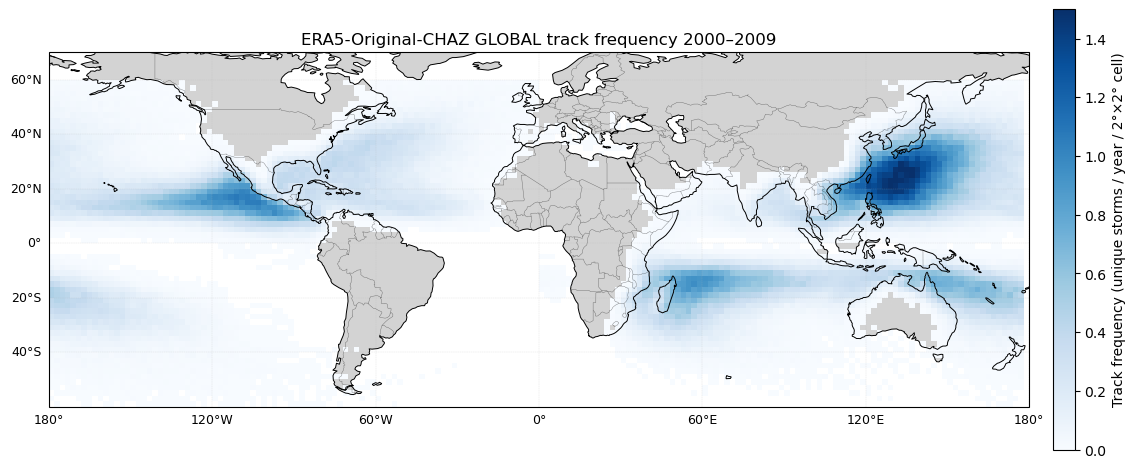

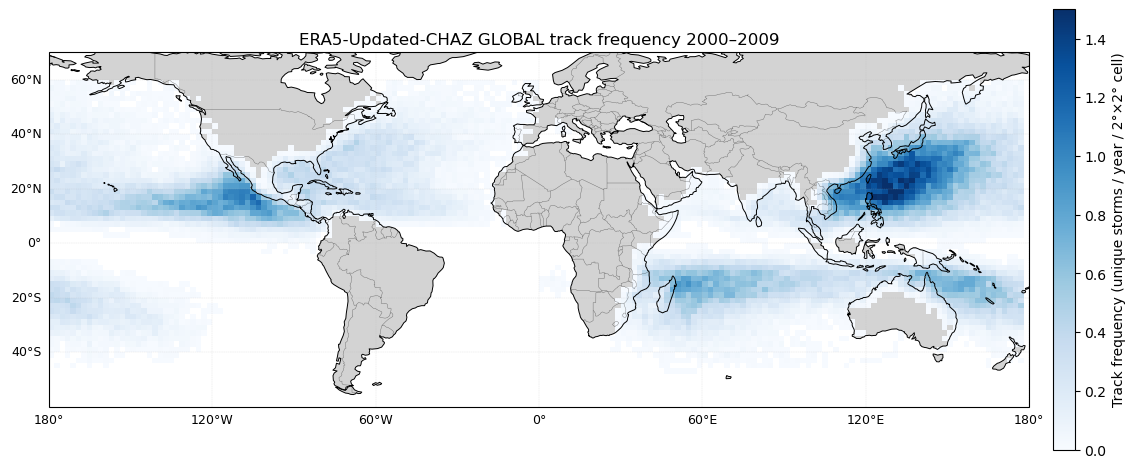

In [8]:
plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_ERA5-Original-CHAZ_GLOBAL.npz",
    extent="global",
    cmap="Blues",
    vmax=1.5,
    horizontal_cbar=False,
)

plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_ERA5-Updated-CHAZ_GLOBAL.npz",
    extent="global",
    cmap="Blues",
    vmax=1.5,
    horizontal_cbar=False,
)

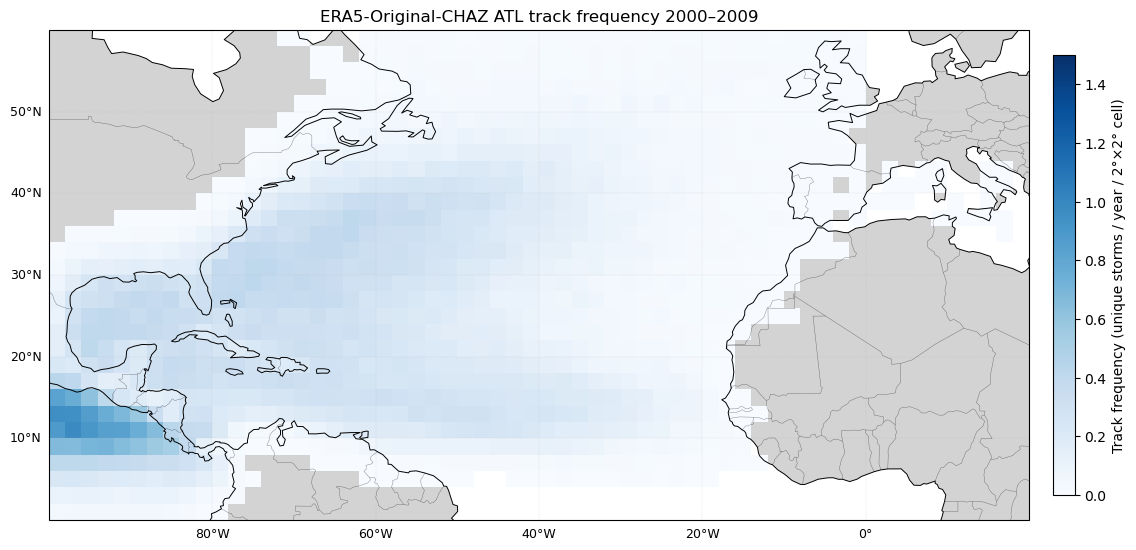

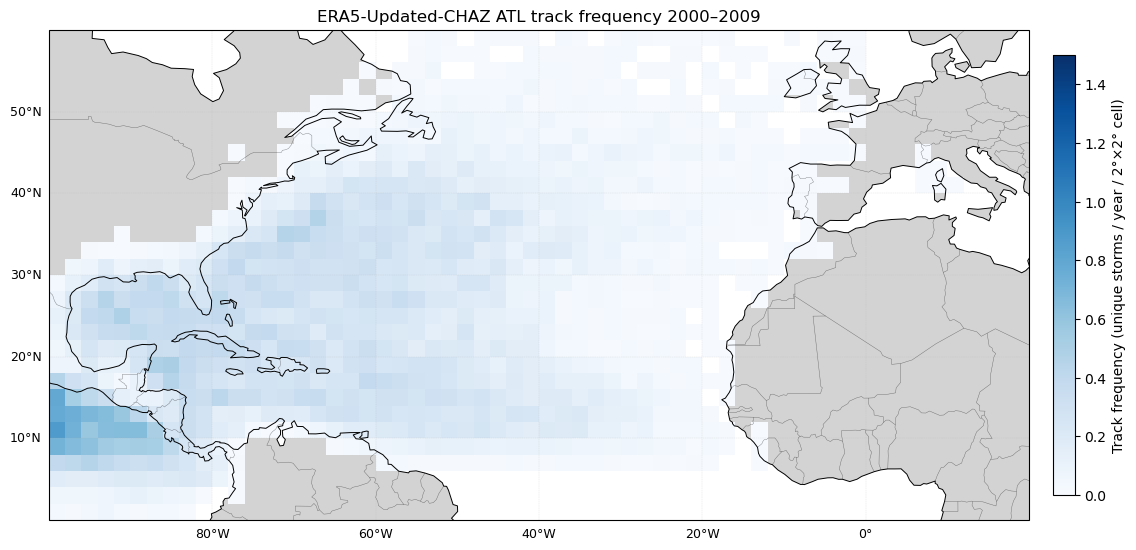

In [9]:
plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_ERA5-Original-CHAZ_ATL.npz",
    extent="auto",
    cmap="Blues",
    vmax=1.5,
    horizontal_cbar=False,
)
plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_ERA5-Updated-CHAZ_ATL.npz",
    extent="auto",
    cmap="Blues",
    vmax=1.5,
    horizontal_cbar=False,
)

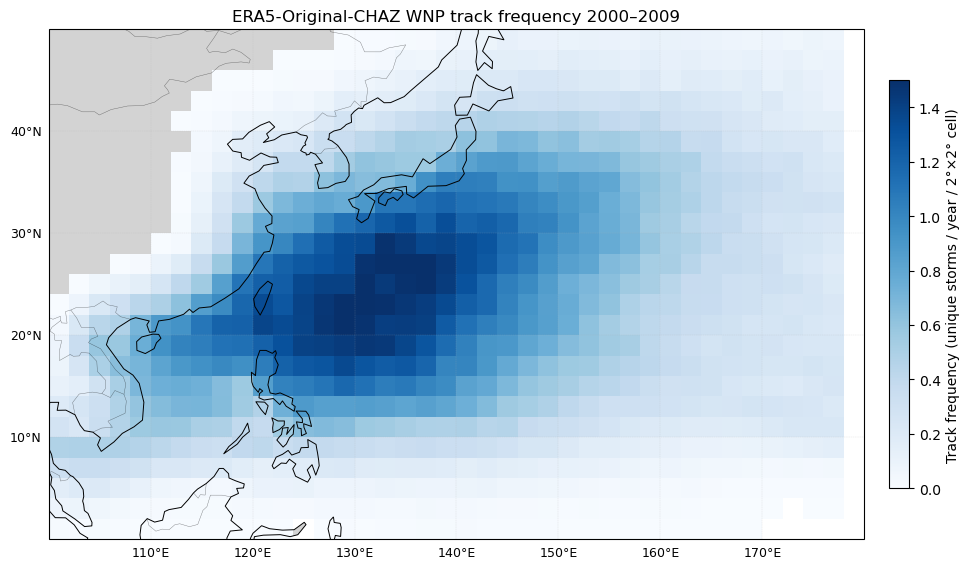

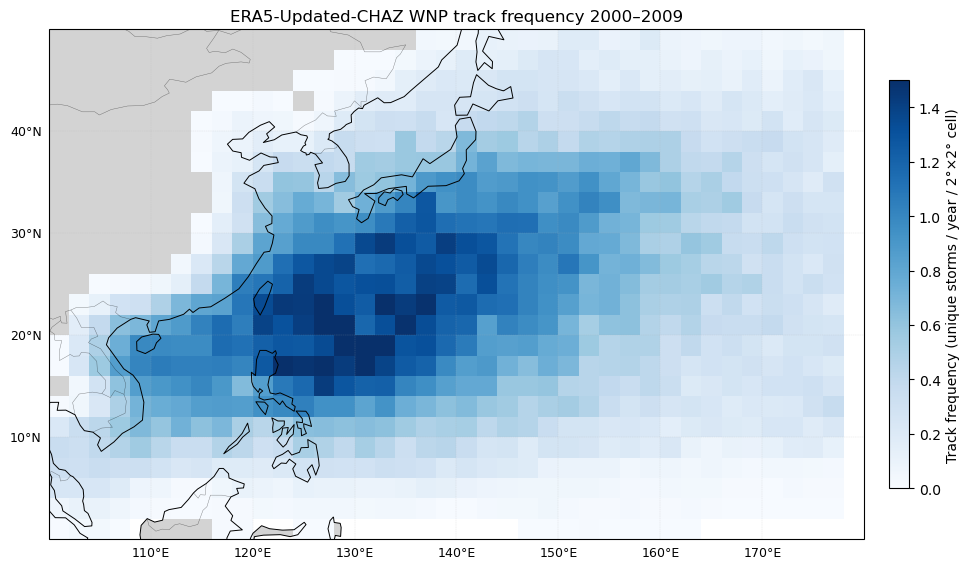

In [10]:
plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_ERA5-Original-CHAZ_WNP.npz",
    extent="auto",
    cmap="Blues",
    vmax=1.5,
    horizontal_cbar=False,
)
plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_ERA5-Updated-CHAZ_WNP.npz",
    extent="auto",
    cmap="Blues",
    vmax=1.5,
    horizontal_cbar=False,
)

In [11]:
def compute_and_save_track_frequency_difference(basin_key):
    npz_path_updated = f"{gv.output_path}/TrackFrequency/track_frequency_ERA5-Updated-CHAZ_{basin_key}.npz"
    npz_path_original = f"{gv.output_path}/TrackFrequency/track_frequency_ERA5-Original-CHAZ_{basin_key}.npz"

    d_updated = np.load(npz_path_updated, allow_pickle=True)
    d_original = np.load(npz_path_original, allow_pickle = True)

    F_updated = d_updated["frequency"].astype(float)
    F_original = d_original["frequency"].astype(float)

    lon_edges_u = d_updated['lon_edges'].astype(float)
    lon_edges_o = d_original['lon_edges'].astype(float)

    lat_edges_u = d_updated['lat_edges'].astype(float)
    lat_edges_o = d_original['lat_edges'].astype(float)

    if (lat_edges_o == lat_edges_u).all() and (lon_edges_o == lon_edges_u).all():
        lon_edges = d_original["lon_edges"].astype(float)
        lat_edges = d_original["lat_edges"].astype(float)
        freq = F_updated - F_original

    else:
        print('Latitude and Longitude edges do not match between comparison versions')


    ### SAVE
    out_root = gv.output_path
    out_dir = os.path.join(out_root, "TrackFrequency")

    outpath = os.path.join(out_dir, f"track_frequency_Updated-Original_differences_{basin_key}.npz")
    np.savez(
        outpath,
        frequency=freq,
        lon_edges=lon_edges,
        lat_edges=lat_edges,
        #nyears_eff=nyears_eff,
        #min_wind_knots=min_wind_knots,
        #dlon=dlon,
        #dlat=dlat,
        basin_key=basin_key,
        definition="difference_in_unique_storms_per_cell_per_year",
        model='difference',
        year_range=np.array((gv.Year1, gv.Year2)),
    )
    print(f"    Saved NPZ: {outpath}")


for basin in ['GLOBAL', 'ATL', 'WNP']:
    compute_and_save_track_frequency_difference(basin)

    Saved NPZ: output/TrackFrequency/track_frequency_Updated-Original_differences_GLOBAL.npz
    Saved NPZ: output/TrackFrequency/track_frequency_Updated-Original_differences_ATL.npz
    Saved NPZ: output/TrackFrequency/track_frequency_Updated-Original_differences_WNP.npz


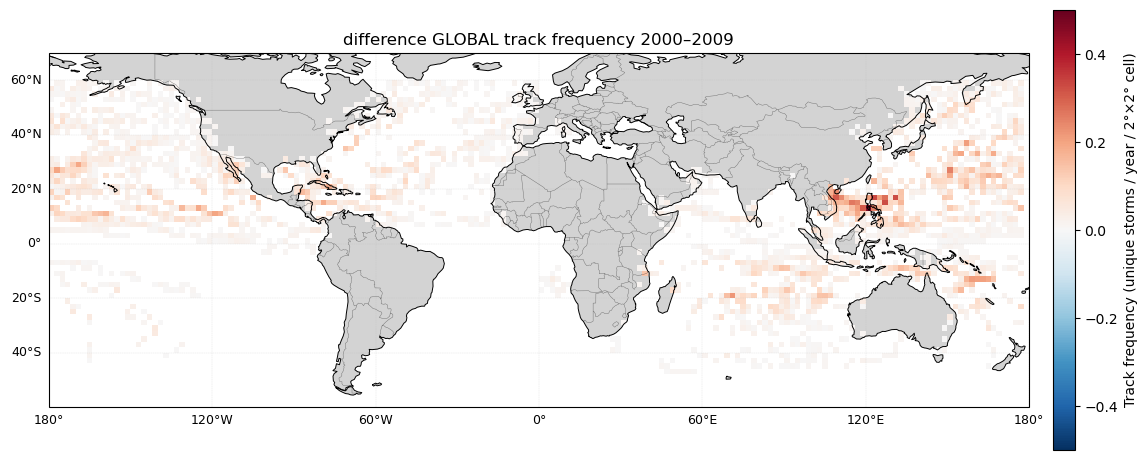

In [12]:
plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_Updated-Original_differences_GLOBAL.npz",
    extent="global",
    cmap="RdBu_r",
    vmax =.5,
    vmin = -.5,
    horizontal_cbar=False,
)

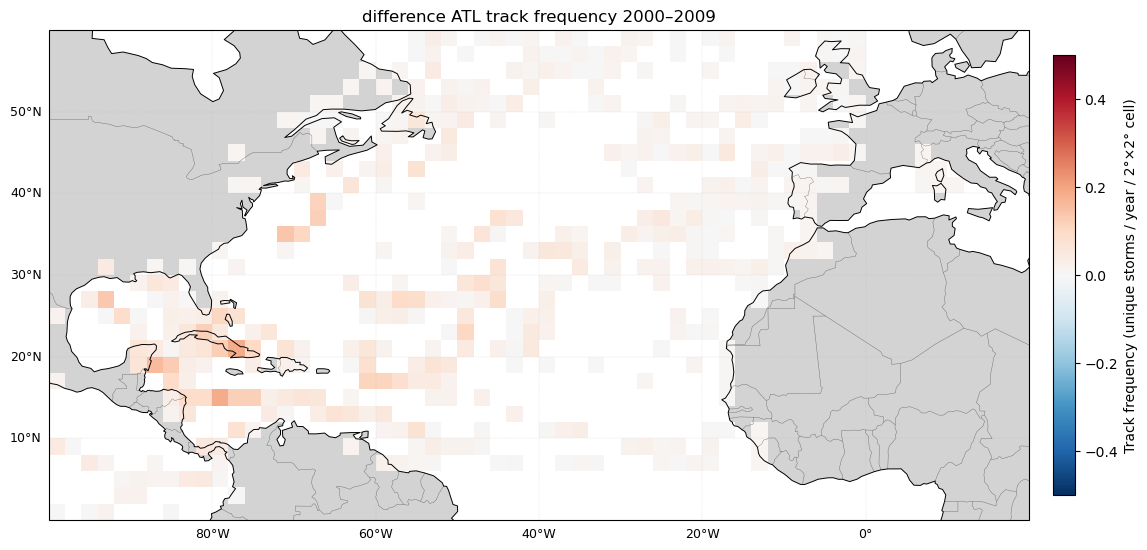

In [13]:
plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_Updated-Original_differences_ATL.npz",
    extent="auto",
    cmap="RdBu_r",
    vmax =.5,
    vmin = -.5,
    horizontal_cbar=False,
)

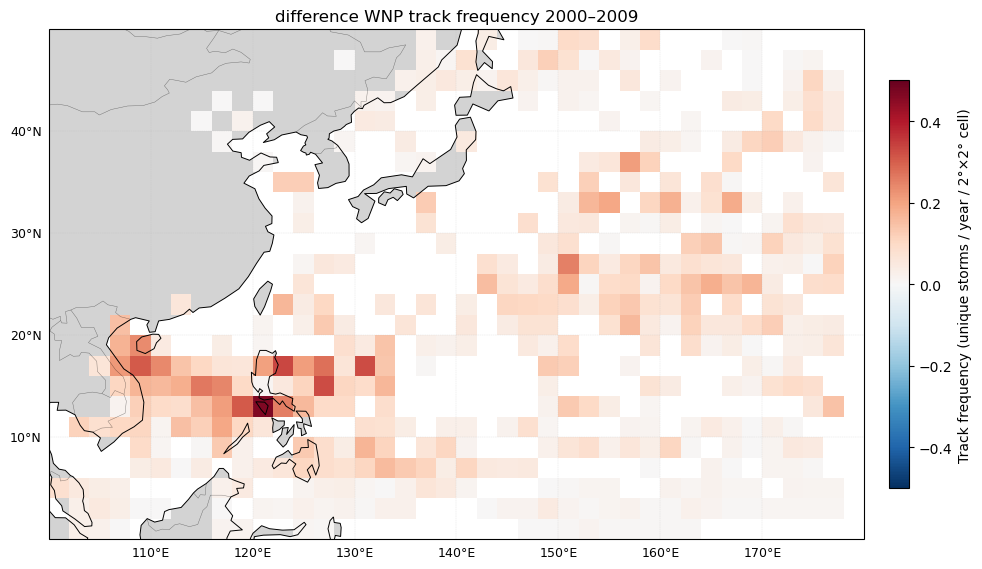

In [14]:
plot_track_frequency_npz(
    f"{gv.output_path}/TrackFrequency/track_frequency_Updated-Original_differences_WNP.npz",
    extent="auto",
    cmap="RdBu_r",
    vmax =.5,
    vmin = -.5,
    horizontal_cbar=False,
)